This book post-processes the experimental measurements of laser beam profiles and the results of LID measurements.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

mpl_params = {
    "text.usetex": True,
    "text.latex.preamble": "\n".join(
        [
            r"\usepackage{bm}",
            r"\usepackage{siunitx}",
            r"\sisetup{detect-all}",
        ]
    ),
    "axes.spines.right": False,
    "axes.spines.top": False,
    "font.family": "sans-serif",
    "font.sans-serif": "Lato",
    "font.size": 20,
    "legend.frameon": False,
    "axes.linewidth": 2,
    "xtick.major.size": 5,
    "xtick.major.width": 2,
    "ytick.major.size": 5,
    "ytick.major.width": 2,
    "xtick.minor.size": 3,
    "xtick.minor.width": 1.5,
    "ytick.minor.size": 3,
    "ytick.minor.width": 1.5,
    "legend.edgecolor": "black",
}

plt.rcParams.update(mpl_params)
mm2inch = 1e-1 / 2.54

## Laser spatial profile

Visualization of the spatial beam profile was done according to this script: https://github.com/mickelsp/jessen-group/blob/master/Python%20Conversions/BeamGage_2DFitting.py

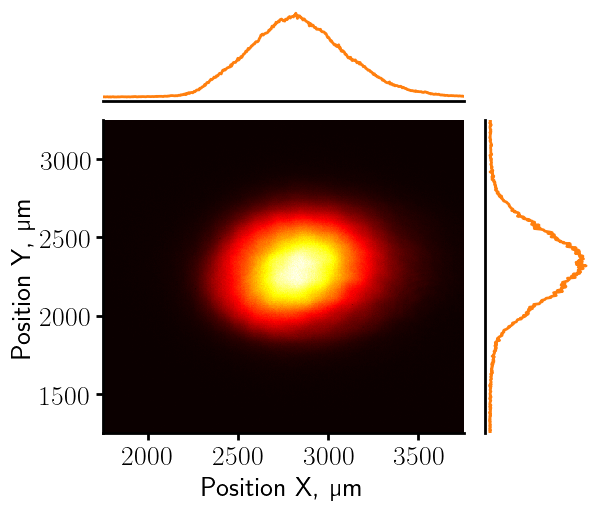

In [ ]:
beamData = np.loadtxt("./beam_profiles/SpatialProfile.csv",delimiter=';',usecols=range(1600))

beamData = np.flipud(beamData)    # Reorder the rows of the array because Python defined the origin differently than the Beam Gage software
beamData = np.rot90(beamData,k=1) # Rotate the array by 90 degrees to make rows be the horizontal (x) data and columns the vertical (y) data
beamData = beamData.ravel()

pixelSizeCal = 4.4                                      #[microns/pixel] Size of each pixel
numPixelsX, numPixelsY = 1200, 1600                     #[pixels] Number of pixels in x and y directions
positionX = np.arange(0,numPixelsX)*pixelSizeCal        #[microns] Position in horizontal direction
positionY = np.arange(0,numPixelsY)*pixelSizeCal        #[microns] Position in vertical direction
positionX,positionY = np.meshgrid(positionX,positionY)  #[microns] Create a grid with same dimensions as x and y axes

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(160*mm2inch, 140*mm2inch))
gs = GridSpec(4, 4)

ax_hist = fig.add_subplot(gs[1:4, 0:3])
ax_line_y = fig.add_subplot(gs[0,0:3])
ax_line_x = fig.add_subplot(gs[1:4, 3])

beamData = beamData.reshape(numPixelsY, numPixelsX)

ax_hist.pcolormesh(positionX, positionY, beamData, cmap="hot")    # Plot the raw data
ax_hist.set_xlabel("Position X, $\si{\micro\meter}$")
ax_hist.set_ylabel("Position Y, $\si{\micro\meter}$")
ax_hist.set_ylim(1250, 3250)
ax_hist.set_xlim(1750, 3750)

ax_line_y.plot(positionX[0,:], beamData[500,:], lw=2, color="tab:orange")
ax_line_y.set_xlim(1750, 3750)
ax_line_y.tick_params(
    axis='both', 
    which='both',
    bottom=False,
    labelbottom=False,   
    left=False,
    labelleft=False)
ax_line_y.spines[['left']].set_visible(False)

ax_line_x.plot(beamData[:,750], positionY[:,0], lw=2, color="tab:orange")
ax_line_x.set_ylim(1250, 3250)
ax_line_x.tick_params(
    axis='both', 
    which='both',
    bottom=False,
    labelbottom=False,   
    left=False,
    labelleft=False)
ax_line_x.spines[['bottom']].set_visible(False)

plt.show()

The measured sparial distribution of laser intensity is close to the gaussian distribution. For both duration of the laser pulse, a single gaussian distribution was used with FWHM=1 mm.

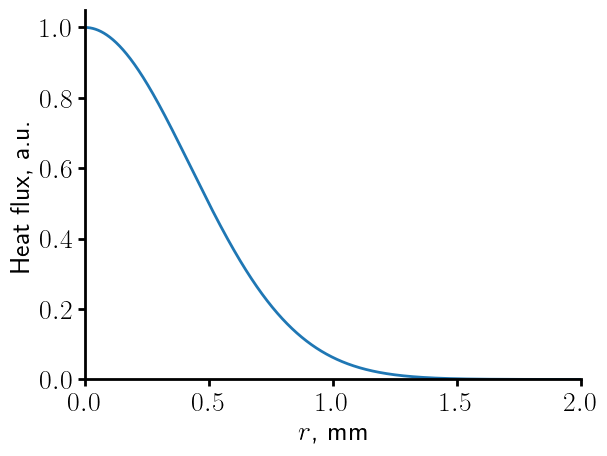

In [171]:
FWHM = 1e-3
sigma_r = FWHM / 2 / np.sqrt(2 * np.log(2))

profile = lambda r: 1 * np.exp(-(r**2) / 2 / sigma_r**2)
r = np.linspace(0, 2e-3, num=10000)

plt.plot(r / 1e-3, profile(r), lw=2)

plt.xlabel(r"$r$, mm")
plt.ylabel("Heat flux, a.u.")
plt.xlim(0, 2)
plt.ylim(0, 1.05)
plt.show()

## Laser temporal profiles

Two duration of laser pulse were used: 1 millisecond and 250 microsecond. We must note that the measured duration of the pulse shell is shorter approximately by 80 microseconds due to the peculiarity of the laser system. For simulations, the measured temporal dependencies were fitted by piece-wise smooth functions.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def fit_func(t, t1, t2, dt1, delta, dt2):
    """
    This function defines a trapezoid-like pulse with exponential leading and trailing edges

    :param t: time
    :type t: s
    """

    return np.piecewise(
        t,
        [t <= t1, (t > t1) & (t <= t2), t > t2],
        [
            lambda t: 1 / (1 + np.exp(-(t - 0.5 * t1) / dt1)),
            lambda t: 1
            / (1 + np.exp(-(t1 - 0.5 * t1) / dt1))
            * (1 - delta * (t - t1) / (t2 - t1)),
            lambda t: 1
            / (1 + np.exp(-(t1 - 0.5 * t1) / dt1))
            * (1 - delta)
            * np.exp(-(t - t2) / dt2),
        ],
    )


durations = ["250us", "1ms"]
popts = []
datas = []

for i, duration in enumerate(durations):
    data = np.loadtxt(
        f"./beam_profiles/TimeProfile_{duration}.csv", delimiter=",", skiprows=1
    )
    datas.append(data)

    popt, _ = curve_fit(
        fit_func, data[:, 0], data[:, 1], p0=[1e-4, 170e-6, 1e-6, 0, 2e-4]
    )
    popts.append(popt)

    times = np.linspace(0, 10e-3, 100000)
    integral = np.trapz(fit_func(times, *popt), x=times)
    print(f"Fitting parameters for {duration}: {popt}, integral = {integral:.5e} s")

Fitting parametrs for 250us: [1.15673172e-04 2.19229191e-04 3.71988035e-06 1.89739539e-02
 1.82511663e-05], integral = 1.78315e-04 s
Fitting parametrs for 1ms: [2.00546392e-04 1.01122924e-03 3.38693378e-07 3.23973591e-02
 1.97812965e-04], integral = 1.08923e-03 s


/tmp/ipykernel_24584/732048609.py:17: RuntimeWarning: overflow encountered in exp
  lambda t: 1 / (1 + np.exp(-(t - 0.5 * t1) / dt1)),


/tmp/ipykernel_24584/732048609.py:17: RuntimeWarning: overflow encountered in exp
  lambda t: 1 / (1 + np.exp(-(t - 0.5 * t1) / dt1)),


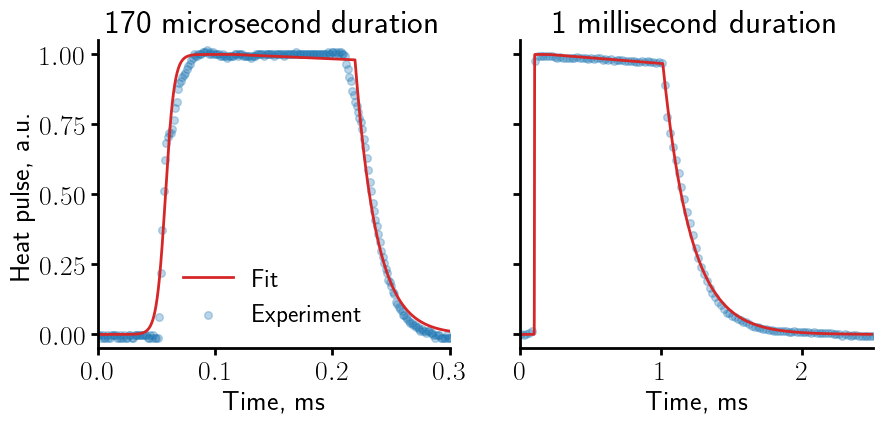

In [169]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

titles = ["170 microsecond duration", "1 millisecond duration"]
for i, duration in enumerate(durations):
    N = int(len(datas[i]) / 250)

    axs[i].plot(
        datas[i][:, 0] / 1e-3,
        fit_func(datas[i][:, 0], *popts[i]),
        label="Fit",
        lw=2,
        color="tab:red",
    )
    axs[i].scatter(
        datas[i][::N, 0] / 1e-3, datas[i][::N, 1], label="Experiment", s=30, alpha=0.3
    )

    axs[i].set_xlabel("Time, ms")
    axs[i].set_title(titles[i])


axs[0].legend(frameon=False, fontsize=18)
axs[0].set_ylabel("Heat pulse, a.u.")
axs[0].set_ylim(-0.05, 1.05)
axs[0].set_xlim(0, 0.3)
axs[1].set_xlim(0, 2.5)
plt.show()

## LID data

Experiments involved a series of laser irradiations of W films with varying beam energy. At each beam energy, multiple laser shots to the same area were performed. In the present work, only first pulse for each laser energy are used.

In [ ]:
pd.options.mode.chained_assignment = None


def get_leak(leak_file):
    """
    Evaluates the QMS signal corresponding to the leak

    :param leak_file: name of a file containing the raw data
    :type leak_file: str
    :return: leak value
    :rtype: float
    """

    data = pd.read_csv(leak_file, skiprows=328, header=None, sep=",").dropna(axis=1)

    data[0] = pd.to_datetime(data[0])
    data[0] = (data[0] - data[0][0]).dt.total_seconds()

    mass3 = data[data[1] == 3.0].reset_index(drop=True).drop(columns=1)
    mass4 = data[data[1] == 4.0].reset_index(drop=True).drop(columns=1)
    mass3 = mass3.rename(columns={0: "Time, s", 2: f"Signal, A"})
    mass4 = mass4.rename(columns={0: "Time, s", 2: f"Signal, A"})
    leak = mass4["Signal, A"][mass4["Time, s"] > 80].mean()

    return leak


def get_first_pulse(data, leak):
    """
    Computes the calibrated QMS signal

    :param data: raw data
    :type data: pd.DataFrame
    :param leak: leak value
    :type leak: float
    :return: cutted data of the first pulse per masses 3 and 4, and the integral amount of desorbed D
    :rtype: list, float
    """

    period = 10
    k = 1.57005e14  # calibration factor

    total_fluence = 0
    max_t = data[1]["Time, s"][data[1]["Signal, A"] == max(data[1]["Signal, A"])].iloc[
        0
    ]

    first_pulse = []

    for i, data in enumerate(data):
        data = data.rolling(10).mean()

        data["Signal, A"] = (
            data["Signal, A"] - data["Signal, A"][data["Time, s"] <= 1].mean()
        )
        noise_max = data["Signal, A"][data["Time, s"] <= 2].max()

        cut_data = data[
            (data["Time, s"] <= max_t + period * 2/3) & (data["Time, s"] > max_t - 2)
        ]

        cut_data["Flow rate, D/s"] = cut_data["Signal, A"] * k / leak / 2 * (i + 1)

        first_pulse.append(cut_data)

        if noise_max * 5 >= cut_data["Signal, A"].max():
            total_fluence += 0  # if the signal below the noise, skip it
        else:

            left_tzero = cut_data["Time, s"][
                (cut_data["Time, s"] < max_t) & (cut_data["Signal, A"] <= 0)
            ].iloc[-1]

            try:
                right_tzero = cut_data["Time, s"][
                    (cut_data["Time, s"] > max_t) & (cut_data["Signal, A"] <= 0)
                ].iloc[0]
            except:
                right_tzero = cut_data["Time, s"].max()

            flow = cut_data["Flow rate, D/s"][
                (cut_data["Time, s"] >= left_tzero)
                & (cut_data["Time, s"] <= right_tzero)
            ]

            time = cut_data["Time, s"][
                (cut_data["Time, s"] >= left_tzero)
                & (cut_data["Time, s"] <= right_tzero)
            ]

            total_fluence += np.trapz(
                y=flow,
                x=time,
            )

    return first_pulse, total_fluence


def get_fluences(folder, name, leak):
    fluences = []
    raw_data = []
    calibrated_first_pulses = []

    for file in sorted(os.listdir(folder)):
        filename = os.fsdecode(file)
        if filename.endswith(".csv") and filename.startswith(name):
            data = pd.read_csv(
                folder + filename, skiprows=328, header=None, sep=","
            ).dropna(axis=1)

            data[0] = pd.to_datetime(data[0])
            data[0] = (data[0] - data[0][0]).dt.total_seconds()

            mass3 = data[data[1] == 3.0].reset_index(drop=True).drop(columns=1)
            mass4 = data[data[1] == 4.0].reset_index(drop=True).drop(columns=1)
            mass3 = mass3.rename(columns={0: "Time, s", 2: f"Signal, A"})
            mass4 = mass4.rename(columns={0: "Time, s", 2: f"Signal, A"})

            separated_data = [mass3, mass4]

            first_pulse, fluence = get_first_pulse(separated_data, leak)

            raw_data.append(separated_data)
            fluences.append(fluence)
            calibrated_first_pulses.append(first_pulse)

    return raw_data, calibrated_first_pulses, fluences


folders = ["./LID_data/250 mks/", "./LID_data/1 ms/"]
names = ["50824", "60824"]
labels = ["170 us", "1 ms"]
laser_energies = [
    [0.054, 0.078, 0.124, 0.171, 0.216, 0.261, 0.306, 0.351],  # 250 us
    [0.066, 0.16, 0.255, 0.34951, 0.444, 0.53771, 0.636, 0.823, 1.003],  # 1 ms
]
raw_datas = []
first_pulses = []
fluences = []
for i, folder in enumerate(folders):

    leak = get_leak(folder + "leak.csv")
    raw_data, first_pulse, fluence_series = get_fluences(folder, names[i], leak)

    raw_datas.append(raw_data)
    first_pulses.append(first_pulse)
    fluences.append(fluence_series)

    export = np.column_stack([laser_energies[i], fluence_series])

    np.savetxt(labels[i] + ".csv", export, header="Energy(J),Fluence(-)", delimiter=",")

### Raw series

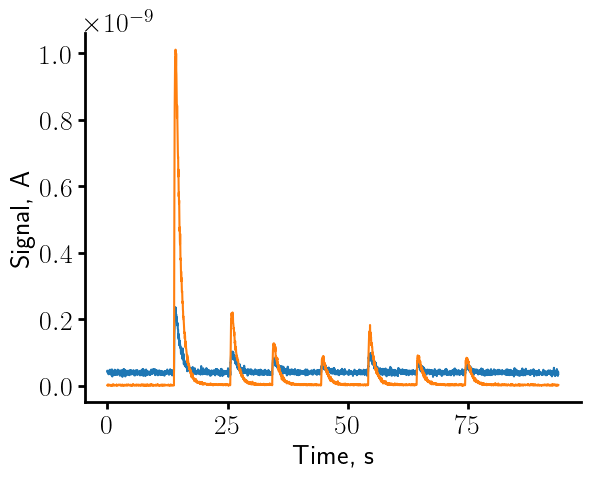

In [161]:
for i in range(2):
    data = raw_datas[1][-1][i]
    plt.plot(data["Time, s"], data["Signal, A"])

plt.ylabel("Signal, A")
plt.xlabel("Time, s")
plt.show()

### First pulses from all series

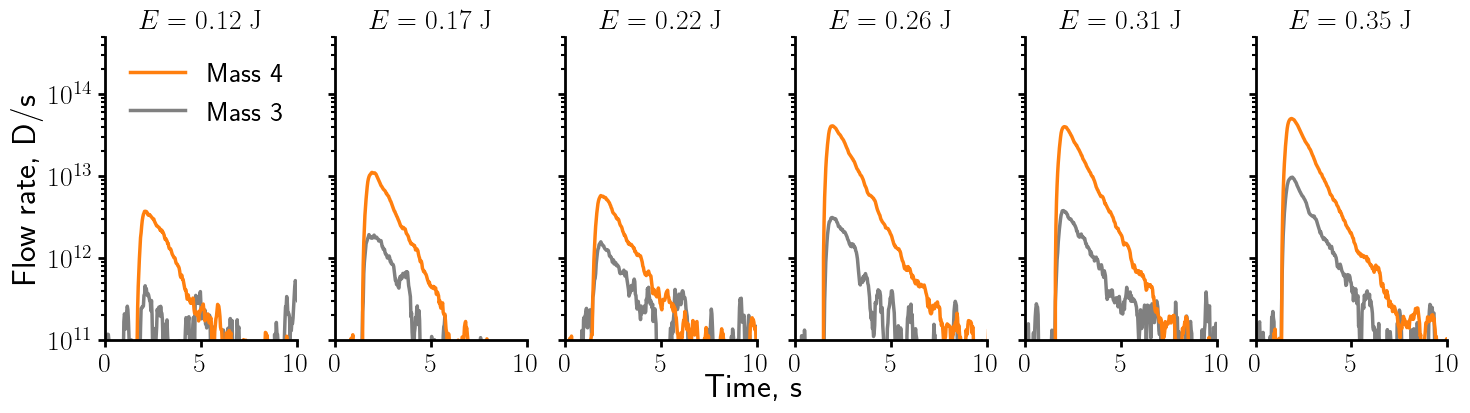

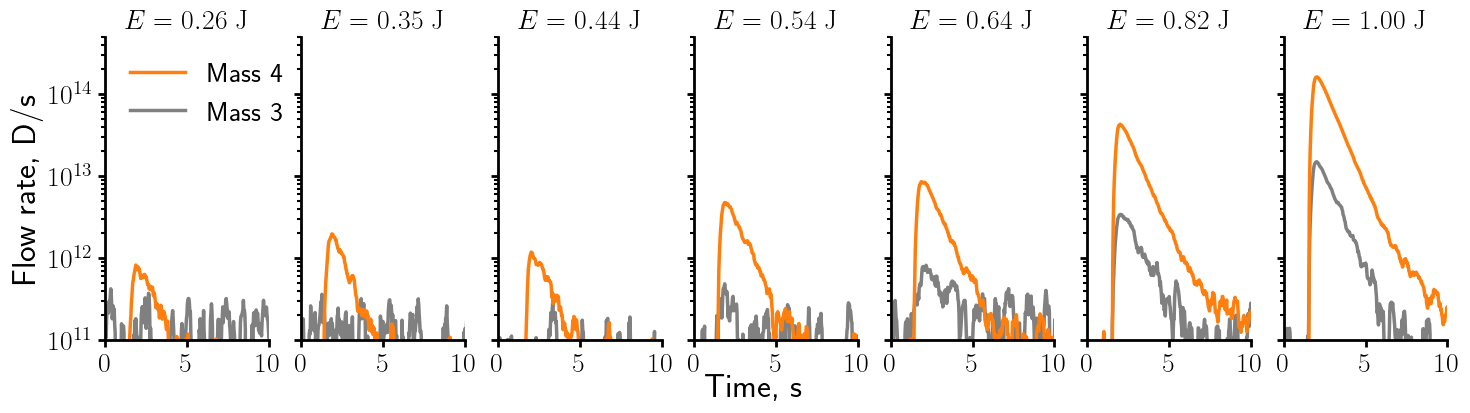

In [5]:
titles = ["170 microsecond duration", "1 millisecond duration"]
colors = ["grey", "tab:orange"]

for i in range(2):
    fig, axs = plt.subplots(
        1, len(first_pulses[i])-2, sharey=True, sharex=True, figsize=(440*mm2inch, 100*mm2inch)
    )

    for j in range(2, len(first_pulses[i])):
        for k in range(2):
            data = first_pulses[i][j][k]
            axs[j-2].plot(
                data["Time, s"] - data["Time, s"].iloc[0],
                data["Flow rate, D/s"],
                label=f"Mass {k+3}",
                lw=2.5,
                color = colors[k]
            )
            axs[j-2].set_title(rf"$E={{{laser_energies[i][j]:.2f}}}~\mathrm{{J}}$", fontsize=20)

    axs[0].set_ylabel("Flow rate, D/s", fontsize=24)
    axs[0].legend(frameon=False, loc=2, reverse=True)
    axs[0].set_yscale("log")
    axs[0].set_ylim(1e11, 5e14)
    axs[0].set_xticks([0, 5, 10])
    axs[0].set_xlim(0,10)
    #fig.suptitle(titles[i], fontweight="bold")
    fig.supxlabel("Time, s", y=-0.05, fontsize=24)
    #if i == 1:
    #    plt.savefig('Series_1ms.svg', bbox_inches="tight", pad_inches=0.02)
    plt.show()

### Dependence of the number of desorbed D on the laser pulse energy

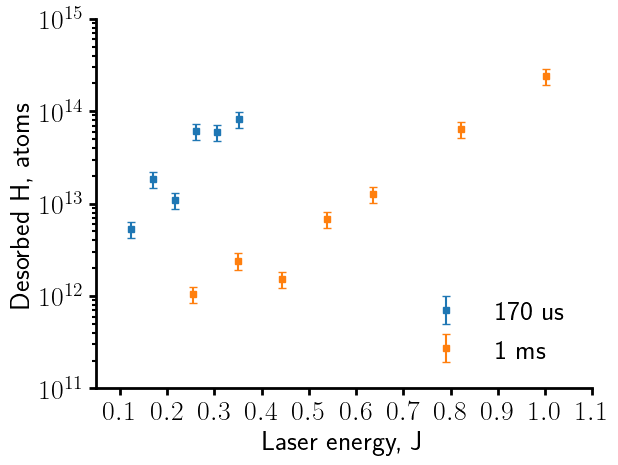

In [152]:
for i, fluence_dat in enumerate(fluences):
    plt.errorbar(
        laser_energies[i],
        np.array(fluence_dat),
        yerr=np.array(fluence_dat) * 0.2,
        fmt="s",
        markersize=5,
        capsize=3,
        label=labels[i],
    )


plt.legend(frameon=False)
plt.yscale("log")
plt.xlim(0.05, 1.05)
plt.ylim(1e11, 1e15)
plt.xticks([i / 10 for i in range(1, 12)])
plt.xlabel("Laser energy, J")
plt.ylabel("Desorbed H, atoms")
plt.show()